In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import os

os.chdir(r'C:\Users\aruna\Desktop\Work\MLDAY1')

df = pd.read_csv('Titanic-Cleaned.csv')
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# random forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(f"Train: {accuracy_score(y_train, rf_model.predict(X_train)):.4f}")
print(f"Test:  {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Train: 0.9789
Test:  0.8212
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       105
           1       0.79      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



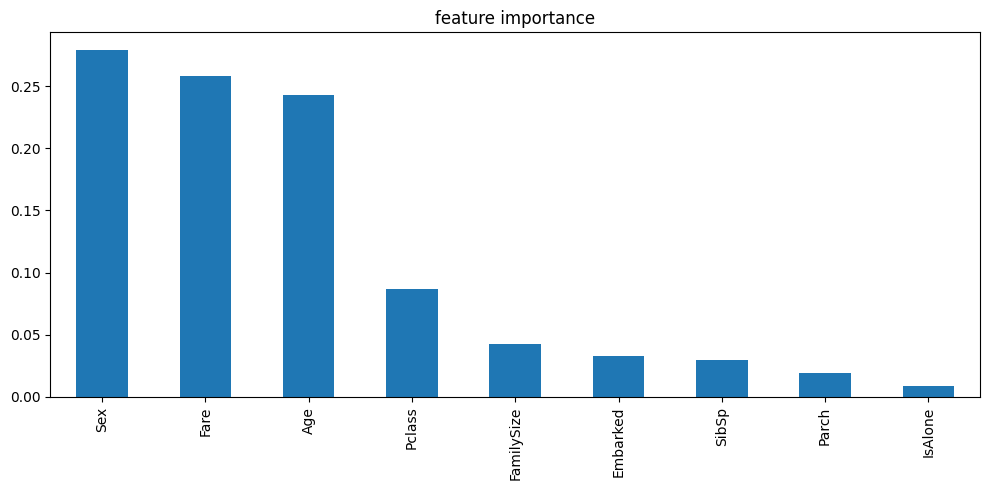

Sex           0.279290
Fare          0.257920
Age           0.242859
Pclass        0.086490
FamilySize    0.042812
Embarked      0.032882
SibSp         0.029642
Parch         0.019079
IsAlone       0.009026
dtype: float64


In [3]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title('feature importance')
plt.tight_layout()
plt.show()
print(importance.sort_values(ascending=False))

In [4]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print(f"Train: {accuracy_score(y_train, xgb_model.predict(X_train)):.4f}")
print(f"Test:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

Train: 0.9607
Test:  0.7989
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

